**The problems in this assignment are sequential. There is no need to load finance_data or text_data from the CSV files for each question.**

In [97]:
import pandas as pd
# read finance data from csv
finance_data = pd.read_csv('./finance_data.csv')
# read text data from csv
text_data = pd.read_csv('./text_data.csv')

# look at the data sample
finance_data.head()
text_data.head()

,ticker,year,quarter,total_word_count,neg,neu,pos,compound
0,SWKS,2022,q1,5408,0.013799,0.794847,0.191359,0.266350
1,CVS,2022,q1,7238,0.011254,0.823173,0.165576,0.294958
2,VNO,2022,q1,8400,0.014297,0.881848,0.103842,0.185106
3,BMY,2022,q1,8107,0.012447,0.816974,0.170585,0.266373
4,LVS,2022,q1,4458,0.021880,0.787235,0.190891,0.206733


**Question 1: If a row in finance_data has null sic_two_digit, that means the financial data could not be effectively extracted from the database. Write code to remove the rows in finance_data if sic_two_digit is null.**

In [98]:
finance_data.dropna(subset=['sic_two_digit'], inplace = True)
print(finance_data)

   ticker  year quarter  sic_two_digit      sales    revenue  net_income  \
0     AAL  2022      q1           45.0   8899.000   8899.000   -1635.000   
1     ADM  2022      q1           20.0  23650.000  23650.000    1054.000   
2     ADP  2022      q1           73.0   3832.300   3832.300     700.500   
3    ADSK  2022      q1           73.0   1170.000   1170.000     146.000   
4     AIG  2022      q1           63.0  14966.000  14966.000    4173.000   
..    ...   ...     ...            ...        ...        ...         ...   
95    WFC  2022      q1           60.0  18688.000        NaN    3788.000   
96    WRK  2022      q1           26.0   4952.200   4952.200     182.300   
97    WST  2022      q1           30.0    720.000    720.000     173.800   
98   WYNN  2022      q1           79.0    953.334    953.334    -183.324   
99   ZION  2022      q1           60.0    697.000        NaN     203.000   

    total_assets  
0       67401.00  
1       64866.00  
2       59987.20  
3        82

**Question 2: After we describe the data, we notice that the revenue column has remaining null values. Write code to fill the null values in revenue with the average of non-null revenue values.**

In [99]:
meanRevenue = finance_data['revenue'].mean()
finance_data["revenue"].fillna(meanRevenue, inplace = True)
print(finance_data)


   ticker  year quarter  sic_two_digit      sales      revenue  net_income  \
0     AAL  2022      q1           45.0   8899.000   8899.00000   -1635.000   
1     ADM  2022      q1           20.0  23650.000  23650.00000    1054.000   
2     ADP  2022      q1           73.0   3832.300   3832.30000     700.500   
3    ADSK  2022      q1           73.0   1170.000   1170.00000     146.000   
4     AIG  2022      q1           63.0  14966.000  14966.00000    4173.000   
..    ...   ...     ...            ...        ...          ...         ...   
95    WFC  2022      q1           60.0  18688.000   8477.40016    3788.000   
96    WRK  2022      q1           26.0   4952.200   4952.20000     182.300   
97    WST  2022      q1           30.0    720.000    720.00000     173.800   
98   WYNN  2022      q1           79.0    953.334    953.33400    -183.324   
99   ZION  2022      q1           60.0    697.000   8477.40016     203.000   

    total_assets  
0       67401.00  
1       64866.00  
2     

/tmp/ipykernel_147956/1976810424.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  finance_data["revenue"].fillna(meanRevenue, inplace = True)


**Question 3: After further examination of the data, we find that there is a wrong entry in the ticker column. Write code to replace the ticker which equals 'BFB' to 'BF.B' in text_data.**

In [100]:
text_data.loc[text_data.index[text_data['ticker'] == 'BFB'], 'ticker'] = "BF.B"
text_data.loc[88] # This shows the corrected ticker symbol

ticker                  BF.B
year                    2022
quarter                   q1
total_word_count        8244
neg                   0.0193
neu                 0.818359
pos                 0.162342
compound            0.258855
Name: 88, dtype: object

**Question 4: Write code to identify the row(s) in text_data whose ticker is not in finance_data.**

In [101]:
finance_tickers = finance_data[['ticker']].drop_duplicates()

joined = text_data.merge(finance_tickers, on='ticker', how='left', indicator=True)
not_in_finance = joined[joined['_merge'] == 'left_only'].drop(columns=['_merge'])
not_in_finance #FRC got removed when we did some cleaning on the finance data sic_two_digit column

,ticker,year,quarter,total_word_count,neg,neu,pos,compound
33,FRC,2022,q1,8017,0.010314,0.811126,0.178553,0.281495


**Question 5: Write code to merge finance_data and text_data on three columns: ticker, year, and quarter. Name the merged DataFrame "merged_data".**

*Hint: If two rows in finance_data and text_data have equal values on all of the three fields (i.e., ticker, year, and quarter), we merge the rows.*

In [102]:
cleanedText = text_data.drop_duplicates(subset=['ticker', 'year', 'quarter'])
cleanedFinance = finance_data.drop_duplicates(subset=['ticker', 'year', 'quarter'])
merged_data = pd.merge(cleanedText, cleanedFinance, on=['ticker', 'year', 'quarter'], how='inner')
print(merged_data)
merged_data.drop_duplicates(subset=['ticker', 'year', 'quarter']) # I thought I understood what the assignment was asking here but was not 100% sure so I dropped duplicates twice.


   ticker  year quarter  total_word_count       neg       neu       pos  \
0    SWKS  2022      q1              5408  0.013799  0.794847  0.191359   
1     CVS  2022      q1              7238  0.011254  0.823173  0.165576   
2     VNO  2022      q1              8400  0.014297  0.881848  0.103842   
3     BMY  2022      q1              8107  0.012447  0.816974  0.170585   
4     LVS  2022      q1              4458  0.021880  0.787235  0.190891   
..    ...   ...     ...               ...       ...       ...       ...   
94    GLW  2022      q1              6679  0.015599  0.834861  0.149538   
95    DHI  2022      q1              7345  0.018516  0.847133  0.134349   
96    TPR  2022      q1              7775  0.012558  0.819818  0.167608   
97    HAS  2022      q1              7866  0.013191  0.807527  0.179287   
98    OXY  2022      q1              8495  0.024520  0.829480  0.145993   

    compound  sic_two_digit      sales    revenue  net_income  total_assets  
0   0.266350         

,ticker,year,quarter,total_word_count,neg,neu,pos,compound,sic_two_digit,sales,revenue,net_income,total_assets
0,SWKS,2022,q1,5408,0.013799,0.794847,0.191359,0.266350,36.0,1510.400,1510.400,399.900,8618.500
1,CVS,2022,q1,7238,0.011254,0.823173,0.165576,0.294958,80.0,76826.000,76826.000,2354.000,232873.000
2,VNO,2022,q1,8400,0.014297,0.881848,0.103842,0.185106,67.0,482.536,482.536,42.007,17492.361
3,BMY,2022,q1,8107,0.012447,0.816974,0.170585,0.266373,28.0,11648.000,11648.000,1278.000,103034.000
4,LVS,2022,q1,4458,0.021880,0.787235,0.190891,0.206733,79.0,955.000,955.000,2530.000,22247.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,GLW,2022,q1,6679,0.015599,0.834861,0.149538,0.262476,36.0,3680.000,3680.000,581.000,30257.000
95,DHI,2022,q1,7345,0.018516,0.847133,0.134349,0.217759,15.0,7061.500,7061.500,1141.600,24999.400
96,TPR,2022,q1,7775,0.012558,0.819818,0.167608,0.346251,31.0,1480.900,1480.900,226.900,8014.100
97,HAS,2022,q1,7866,0.013191,0.807527,0.179287,0.316508,39.0,1163.100,1163.100,61.200,9518.700


**Question 6: Write code to count the number of rows for each unique sic_two_digit in merged_data**

In [103]:
merged_data.drop_duplicates(subset=['sic_two_digit'], keep='first')['sic_two_digit'].count() #There are 30 distinct records in this row

np.int64(30)

**Question 7: Add a new column labeled as industry to merged_data. If sic_two_digit is 36, industry equals 'Electronics'. If sic_two_digit is 28, industry equals 'Chemicals'. If sic_two_digit is 73, industry is 'Business Services'. For other sic_two_digit values, industry is 'Others'**

In [104]:
merged_data['industry'] = 'Others'
merged_data.loc[merged_data.index[merged_data['sic_two_digit'] == 28], 'industry'] = "Chemicals"
merged_data.loc[merged_data.index[merged_data['sic_two_digit'] == 36], 'industry'] = "Electronics"
merged_data.loc[merged_data.index[merged_data['sic_two_digit'] == 73], 'industry'] = "Business Services"


**Question 8: Write code to answer the following question: for each industry (i.e., Electronics, Chemicals, Business Services and Others), what is the average revenue and average total_word_count?**

In [105]:
merged_data[['industry', 'revenue']].groupby('industry').mean()

,revenue
industry,
Business Services,3110.753300
Chemicals,7030.797091
Electronics,4168.828833
Others,10315.005588


**Question 9: Write code to answer the following question: what is the correlation between a company's return on asset and its compound sentiment score?**

*Hint: Return on asset is net income divided by total assets.*

In [106]:
correlationTable = merged_data[['net_income','total_assets','compound']]
correlationTable['return_on_asset'] = correlationTable['net_income']/correlationTable['total_assets']
print(correlationTable)
correlationTable[['return_on_asset','compound']].corr()

    net_income  total_assets  compound  return_on_asset
0      399.900      8618.500  0.266350         0.046400
1     2354.000    232873.000  0.294958         0.010109
2       42.007     17492.361  0.185106         0.002401
3     1278.000    103034.000  0.266373         0.012404
4     2530.000     22247.000  0.206733         0.113723
..         ...           ...       ...              ...
94     581.000     30257.000  0.262476         0.019202
95    1141.600     24999.400  0.217759         0.045665
96     226.900      8014.100  0.346251         0.028313
97      61.200      9518.700  0.316508         0.006429
98    4876.000     74222.000  0.233405         0.065695

[99 rows x 4 columns]


/tmp/ipykernel_147956/2040669128.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  correlationTable['return_on_asset'] = correlationTable['net_income']/correlationTable['total_assets']


,return_on_asset,compound
return_on_asset,1.000000,0.024538
compound,0.024538,1.000000


**Question 10: Plot a scatter plot with return on asset and compound sentiment score on the x-axis and y-axis, respectively. Explain the pattern that you see in the plot.**

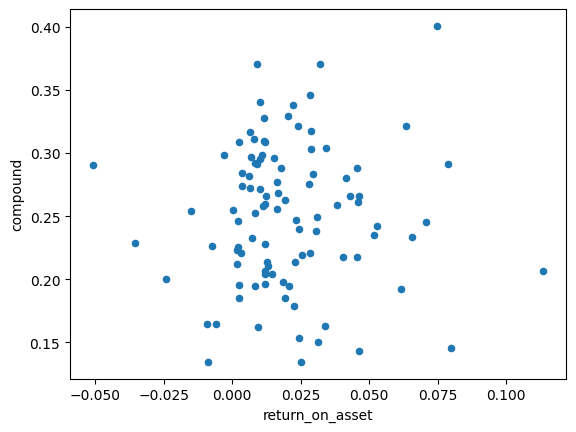

In [108]:
import matplotlib.pyplot as plt
correlationTable.plot(kind = 'scatter', x='return_on_asset',y='compound')
plt.show()

After looking at this data, I do not see much of a pattern or correlation here.
The data in this figure seems to be vertical, particularly above the region where 0.01 to 0.02 is